In [ ]:
!pip install -q scikit-learn pandas

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
INPUT_PATH = '/content/drive/MyDrive/KOPIS/data/complex2324_last.csv'
OUT_DIR    = "/content/drive/MyDrive/KOPIS/Hyeon"

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
import os; os.makedirs(OUT_DIR, exist_ok=True)

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module='matplotlib')


In [ ]:
# 저변 중심 가중치
W_U_PAID, W_S_PAID, W_A_PAID = 0.45, 0.35, 0.20
W_U_FREE, W_S_FREE           = 0.60, 0.40

# 접근성(편의) 보너스 민감도/캡
BETA_INCLUSION   = 0.10     # 0.05~0.15 권장
BONUS_MULTIPLIER_CAP = (0.90, 1.10)  # 최종 보너스 계수 클립 범위(±10%)

# 가드레일(유료, 회차당매출 하위20% → ×0.95)
GUARD_PENALTY    = 0.95

# 지역 보정(디밍) 수축/캡
REGION_SHRINK_K  = 60       # 클수록 보수적(보정 약함)
REGION_CAP_ABS   = 5.0      # 최대 ±5점만 이동

usecols = [
    "공연명","예매금액_합계","판매좌석수_합계","총_공연회차_계산","최종_좌석점유율",
    "평균_판매좌석수","평균판매단가","회차당매출","접근성_점수",
    "장르명","지역","공연시설명",
    # 아래 3개는 계산에는 쓰지 않지만 리포트에 포함 가능(있으면 로드됨)
    "예측복합장르","장르1","장르2"
]

# 인코딩 자동 처리
loaded = False
for enc in ["utf-8-sig","cp949","utf-8"]:
    try:
        df = pd.read_csv(INPUT_PATH, usecols=[c for c in usecols if c], encoding=enc)
        print(f"Loaded with {enc} →", df.shape)
        loaded = True
        break
    except FileNotFoundError:
        raise
    except Exception as e:
        print(enc, "failed:", e)
if not loaded:
    raise RuntimeError("CSV 로드 실패: 인코딩/경로 확인 필요")




Loaded with utf-8-sig → (576, 15)


In [ ]:
# =========================
# 2) 전처리 & 유틸 (전역 기준)
# =========================
# 숫자형 변환
num_cols = ["예매금액_합계","판매좌석수_합계","총_공연회차_계산","최종_좌석점유율",
            "평균_판매좌석수","평균판매단가","회차당매출","접근성_점수"]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# 접근성 점수 0~11로 클립
if "접근성_점수" in df.columns:
    df["접근성_점수"] = df["접근성_점수"].clip(lower=0, upper=11)

# 전역 윈저/백분위(코호트 없음)
def winsor_global(s: pd.Series, a=0.05, b=0.95):
    lo, hi = s.quantile(a), s.quantile(b)
    return s.clip(lo, hi)

def pct_rank_global(s: pd.Series):
    return s.rank(pct=True, method="average")

In [ ]:
# =========================
# 3) U/S/A 계산 (전역 정규화)
# =========================
# U: 참여(좌석활용)
p_occ = pct_rank_global(winsor_global(df["최종_좌석점유율"].astype(float)))
U = p_occ.clip(0,1)

# S: 접점/규모 (0.5*회차 + 0.3*판매좌석수 + 0.2*평균판매좌석수)
p_perf = pct_rank_global(winsor_global(np.log1p(df["총_공연회차_계산"].fillna(0).clip(lower=0))))
p_sold = pct_rank_global(winsor_global(np.log1p(df["판매좌석수_합계"].fillna(0).clip(lower=0))))
p_avg  = pct_rank_global(winsor_global(df["평균_판매좌석수"].astype(float)))
S = (0.5*p_perf + 0.3*p_sold + 0.2*p_avg).clip(0,1)

# A: 가격 접근성 (단가가 낮을수록 좋음)
p_price = pct_rank_global(winsor_global(df["평균판매단가"].astype(float)))
A = (1 - p_price).clip(0,1)

# 유/무료 구분
is_free = ((df["평균판매단가"].fillna(0) <= 0) | (df["회차당매출"].fillna(0) <= 0))

# Core DPI (기하평균)
def geo(u,s,a,wu,ws,wa):
    g = (np.clip(u,1e-9,1)**wu) * (np.clip(s,1e-9,1)**ws) * (np.clip(a,1e-9,1)**wa)
    return 100 * (g ** (1.0/(wu+ws+wa)))

DPI_core_paid = geo(U,S,A, W_U_PAID, W_S_PAID, W_A_PAID)
DPI_core_free = 100 * ((np.clip(U,1e-9,1)**W_U_FREE)*(np.clip(S,1e-9,1)**W_S_FREE))
DPI_core = np.where(is_free, DPI_core_free, DPI_core_paid)

In [ ]:
# =========================
# 4) 접근성(편의) 보너스 (전역 평균 대비, 완만 변환 + 캡)
# =========================
# 원점수 → 0~1 스케일 → 퍼센타일 → √(체감) → 전역 평균 대비 ±β → 0.90~1.10 캡
I_raw  = (df["접근성_점수"].fillna(0) / 11.0).clip(0,1)
I_pct  = pct_rank_global(winsor_global(I_raw))
I_tame = np.sqrt(I_pct)  # 상위에 약간만 보너스 주는 완만 변환
Ibar   = float(I_tame.mean())

mult   = 1 + BETA_INCLUSION * (I_tame - Ibar)
mult   = mult.clip(BONUS_MULTIPLIER_CAP[0], BONUS_MULTIPLIER_CAP[1])

DPI_plus = DPI_core * mult

# 가드레일(유료): 회차당매출 전역 하위 20% → -5%
p_rev = pct_rank_global(winsor_global(df["회차당매출"].astype(float)))
guard = np.where((~is_free) & (p_rev < 0.20), GUARD_PENALTY, 1.00)
DPI_plus = DPI_plus * guard

In [ ]:
# ==== 드롭인 패치 (ndarray -> Series 정렬 + 표준 컬럼 등록) ====
import numpy as np
import pandas as pd

df = df.copy()

# 0) 길이 점검(선택)
n = len(df)
for name, arr in [("U", U), ("S", S), ("A", A), ("is_free", is_free), ("DPI_core", DPI_core)]:
    if len(arr) != n:
        raise ValueError(f"{name} 길이 {len(arr)} != df 길이 {n}")

# 1) U/S/A/무료여부 -> 표준 컬럼 (Series로 등록, 인덱스 정렬)
df["U_participation"] = pd.to_numeric(pd.Series(U, index=df.index), errors="coerce").astype(float)
df["S_scale"]         = pd.to_numeric(pd.Series(S, index=df.index), errors="coerce").astype(float)
df["A_afford"]        = pd.to_numeric(pd.Series(A, index=df.index), errors="coerce").astype(float)
df["is_free"]         = pd.Series(is_free, index=df.index).astype(bool)

# 2) DPI_plus 채우기 (기존 것이 NaN이면 DPI_core로)
dpi_core_s = pd.to_numeric(pd.Series(DPI_core, index=df.index), errors="coerce")

if "DPI_plus" in df.columns:
    df["DPI_plus"] = pd.to_numeric(df["DPI_plus"], errors="coerce")
    # 방법 A: combine_first (Series끼리 정렬돼서 안전)
    df["DPI_plus"] = df["DPI_plus"].combine_first(dpi_core_s)
    # (대안) 방법 B: where
    # df["DPI_plus"] = np.where(df["DPI_plus"].notna(), df["DPI_plus"], dpi_core_s)
else:
    df["DPI_plus"] = dpi_core_s

# 3) Sanity check
_need = ["U_participation","S_scale","A_afford","is_free","DPI_plus"]
_missing = [c for c in _need if c not in df.columns or df[c].isna().all()]
if _missing:
    raise RuntimeError(f"필수 컬럼 누락/전부 NaN: {_missing}. U/S/A/DPI_core 계산 확인 필요.")


In [ ]:
# ==========================================
# 세그먼트별(K, CAP) 하이퍼파라미터 탐색 & 최적 선택
# 전제: df에 'DPI_plus', '지역', 'is_free' 존재 (없으면 is_free는 가격/매출로 생성)
# ==========================================
import numpy as np
import pandas as pd

# ---- 안전장치 (is_free 없으면 생성)
if "is_free" not in df.columns:
    price = pd.to_numeric(df.get("평균판매단가", 0), errors="coerce").fillna(0)
    rev   = pd.to_numeric(df.get("회차당매출", 0),   errors="coerce").fillna(0)
    df["is_free"] = (price <= 0) | (rev <= 0)

df["segment"] = np.where(df["is_free"], "Free", "Paid")

# ---- 필수 컬럼 체크
for c in ["DPI_plus", "지역", "segment"]:
    if c not in df.columns:
        raise KeyError(f"필수 컬럼 없음: {c}")

# ---- 평가 그리드(원하면 수정)
K_GRID   = [30, 60, 80, 100, 150]     # 수축 정도
CAP_GRID = [2.0, 3.0, 4.0, 5.0, 6.0]  # 이동 한도(점수)

# ---- 스코어 가중치(원하면 조정)
W_ETA   = 0.40   # 지역효과(η²) 낮출수록 좋음
W_RMS   = 0.30   # 지역 평균의 RMS 편차 낮출수록 좋음
W_DIST  = 0.15   # 왜곡 크기(Δ)의 95퍼센타일 낮출수록 좋음
W_RANK  = 0.15   # (1 - Spearman) 낮을수록 좋음 → Spearman 높을수록 좋음
RANK_FLOOR = 0.90  # 스피어만이 이보다 낮으면 패널티 부여
RANK_PENALTY = 0.20  # 패널티 가산

def _eta2(y: pd.Series, by: pd.Series) -> float:
    """ANOVA eta-squared (between / total). NaN 안전."""
    s = pd.to_numeric(y, errors="coerce")
    m = s.mean()
    # 그룹별 평균과 크기
    g = s.groupby(by, dropna=False)
    mu = g.transform("mean")
    n  = g.transform("size")
    ss_between = ((mu - m)**2).groupby(by, dropna=False).apply(lambda z: z.iloc[0] * n.loc[z.index[0]]).sum()
    ss_total   = ((s - m)**2).sum()
    if ss_total == 0 or np.isnan(ss_total):
        return 0.0
    return float(ss_between / ss_total)

def _region_rms(y: pd.Series, by: pd.Series) -> float:
    """지역 평균의 전역평균 대비 RMS 편차(가중=지역 표본비율)."""
    s = pd.to_numeric(y, errors="coerce")
    m = s.mean()
    g = s.groupby(by, dropna=False)
    mu = g.mean()
    n  = g.size()
    if n.sum() == 0:
        return 0.0
    w = n / n.sum()
    return float(np.sqrt(((mu - m)**2 * w).sum()))

def _adjust_segment(seg_df: pd.DataFrame, K: float, CAP: float) -> pd.Series:
    """세그먼트 내부에서 지역별 디밍+수축+캡 적용 후 adj 시리즈 반환."""
    s  = pd.to_numeric(seg_df["DPI_plus"], errors="coerce")
    by = seg_df["지역"]
    g  = s.groupby(by, dropna=False)
    mu_region = g.transform("mean")
    mu_all    = float(s.mean())
    n_region  = g.transform("size")
    alpha = (n_region / (n_region + K)).clip(0,1)
    delta = np.clip(alpha * (mu_region - mu_all), -CAP, CAP)
    adj = s - delta
    return adj, (adj - s), np.abs(adj - s) >= (CAP - 1e-12)

def _spearman(a: pd.Series, b: pd.Series) -> float:
    try:
        r = a.corr(b, method="spearman")
        if pd.isna(r):  # 상수열 등
            return 1.0
        return float(r)
    except Exception:
        return 1.0

def _top_overlap(a: pd.Series, b: pd.Series, n=10) -> float:
    ia = a.rank(ascending=False, method="first").nsmallest(n).index
    ib = b.rank(ascending=False, method="first").nsmallest(n).index
    return len(set(ia) & set(ib)) / max(1, n)

def evaluate_segment(seg_name: str, seg_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    y0 = pd.to_numeric(seg_df["DPI_plus"], errors="coerce")
    by = seg_df["지역"]
    eta_pre = _eta2(y0, by)
    rms_pre = _region_rms(y0, by)

    for K in K_GRID:
        for CAP in CAP_GRID:
            adj, delta, sat = _adjust_segment(seg_df, K, CAP)
            eta_post = _eta2(adj, by)
            rms_post = _region_rms(adj, by)
            sp       = _spearman(y0, adj)
            d_mean   = float(np.abs(delta).mean())
            d_p95    = float(np.percentile(np.abs(delta.dropna()), 95)) if delta.notna().any() else 0.0
            sat_rate = float(np.mean(sat)) if len(sat) else 0.0
            top_ov   = _top_overlap(y0, adj, n=10)

            rows.append({
                "segment": seg_name,
                "K": K, "CAP": CAP,
                "eta_pre": eta_pre, "eta_post": eta_post, "eta_reduction": eta_pre - eta_post,
                "rms_pre": rms_pre, "rms_post": rms_post, "rms_reduction": rms_pre - rms_post,
                "spearman": sp, "top10_overlap": top_ov,
                "dist_mean_abs": d_mean, "dist_p95": d_p95, "cap_saturation_rate": sat_rate
            })
    res = pd.DataFrame(rows)

    # ---- 점수화(작을수록 좋음) : min-max 정규화
    def _minmax(s):
        v = s.values.astype(float)
        v = (v - np.nanmin(v)) / (np.nanmax(v) - np.nanmin(v) + 1e-12)
        return pd.Series(v, index=s.index)

    if not res.empty:
        bad_eta  = _minmax(res["eta_post"])       # ↓
        bad_rms  = _minmax(res["rms_post"])       # ↓
        bad_dist = _minmax(res["dist_p95"])       # ↓
        bad_rank = _minmax(1 - res["spearman"])   # ↓ (스피어만 높을수록 좋음)
        score = W_ETA*bad_eta + W_RMS*bad_rms + W_DIST*bad_dist + W_RANK*bad_rank

        # 스피어만 하한선 미달 시 패널티
        score += np.where(res["spearman"] < RANK_FLOOR, RANK_PENALTY, 0.0)
        res["score"] = score

        res = res.sort_values(["score","eta_post","rms_post","dist_p95"], ascending=True).reset_index(drop=True)
    return res

# ===== 세그먼트별 평가 실행
results = []
for seg in ["Paid","Free"]:
    seg_df = df[df["segment"] == seg]
    if len(seg_df) == 0:
        print(f"{seg}: 데이터 없음")
        continue
    res = evaluate_segment(seg, seg_df)
    results.append(res)
    print(f"\n=== 후보표: {seg} (상위 10) ===")
    display(res.head(10))

# ===== 최적값 자동 선택 및 적용(원하면 True로)
APPLY_BEST = True

if results:
    best_params = {}
    for res in results:
        seg = res.loc[0, "segment"]
        K_best  = res.loc[0, "K"]
        CAP_best= res.loc[0, "CAP"]
        best_params[seg] = {"K": float(K_best), "CAP": float(CAP_best)}
        print(f"[BEST] {seg} → K={K_best}, CAP={CAP_best} | score={res.loc[0,'score']:.4f}, "
              f"eta_post={res.loc[0,'eta_post']:.4f}, spearman={res.loc[0,'spearman']:.3f}, "
              f"rms_post={res.loc[0,'rms_post']:.3f}, d95={res.loc[0,'dist_p95']:.2f}, cap_sat={res.loc[0,'cap_saturation_rate']:.2%}")

    if APPLY_BEST:
        # 결과 컬럼 새로 계산/적용
        for c in ["DPI_region_adj_seg","DPI_region_pr_seg","region_delta_seg"]:
            df[c] = np.nan

        for seg, hp in best_params.items():
            idx = (df["segment"] == seg)
            if not idx.any(): continue
            seg_df = df.loc[idx]
            # 적용
            adj, delta, _ = _adjust_segment(seg_df, hp["K"], hp["CAP"])
            pr = seg_df["DPI_plus"].groupby(seg_df["지역"], dropna=False).rank(pct=True, method="average")
            df.loc[idx, "DPI_region_adj_seg"] = adj.values
            df.loc[idx, "DPI_region_pr_seg"]  = pr.values
            df.loc[idx, "region_delta_seg"]   = (adj - seg_df["DPI_plus"]).values

        print("\n✅ 최적 K/CAP 적용 완료 → `DPI_region_adj_seg` 사용하세요.")
else:
    print("평가 결과가 없습니다.")



=== 후보표: Paid (상위 10) ===


,segment,K,CAP,eta_pre,eta_post,eta_reduction,rms_pre,rms_post,rms_reduction,spearman,top10_overlap,dist_mean_abs,dist_p95,cap_saturation_rate,score
0,Paid,30,2.0,0.022972,0.014144,0.008828,2.437959,1.904413,0.533546,0.997874,0.9,0.873880,1.827599,0.0,0.300000
1,Paid,30,3.0,0.022972,0.014144,0.008828,2.437959,1.904413,0.533546,0.997874,0.9,0.873880,1.827599,0.0,0.300000
2,Paid,30,4.0,0.022972,0.014144,0.008828,2.437959,1.904413,0.533546,0.997874,0.9,0.873880,1.827599,0.0,0.300000
3,Paid,30,5.0,0.022972,0.014144,0.008828,2.437959,1.904413,0.533546,0.997874,0.9,0.873880,1.827599,0.0,0.300000
4,Paid,30,6.0,0.022972,0.014144,0.008828,2.437959,1.904413,0.533546,0.997874,0.9,0.873880,1.827599,0.0,0.300000
5,Paid,60,2.0,0.022972,0.016178,0.006794,2.437959,2.038844,0.399115,0.998747,0.9,0.660032,1.225094,0.0,0.452871
6,Paid,60,3.0,0.022972,0.016178,0.006794,2.437959,2.038844,0.399115,0.998747,0.9,0.660032,1.225094,0.0,0.452871
7,Paid,60,4.0,0.022972,0.016178,0.006794,2.437959,2.038844,0.399115,0.998747,0.9,0.660032,1.225094,0.0,0.452871
8,Paid,60,5.0,0.022972,0.016178,0.006794,2.437959,2.038844,0.399115,0.998747,0.9,0.660032,1.225094,0.0,0.452871
9,Paid,60,6.0,0.022972,0.016178,0.006794,2.437959,2.038844,0.399115,0.998747,0.9,0.660032,1.225094,0.0,0.452871



=== 후보표: Free (상위 10) ===


,segment,K,CAP,eta_pre,eta_post,eta_reduction,rms_pre,rms_post,rms_reduction,spearman,top10_overlap,dist_mean_abs,dist_p95,cap_saturation_rate,score
0,Free,30,6.0,0.071008,0.013316,0.057691,5.856994,2.461097,3.395897,0.987092,0.5,2.880409,5.568061,0.000000,0.300000
1,Free,30,5.0,0.071008,0.015541,0.055466,5.856994,2.661802,3.195193,0.989012,0.5,2.752317,5.000000,0.225490,0.305477
2,Free,30,4.0,0.071008,0.020261,0.050746,5.856994,3.046554,2.810440,0.990968,0.6,2.508950,4.000000,0.431373,0.348710
3,Free,60,4.0,0.071008,0.025866,0.045141,5.856994,3.452130,2.404865,0.994010,0.9,2.022187,3.992194,0.000000,0.432797
4,Free,60,5.0,0.071008,0.025866,0.045141,5.856994,3.452130,2.404865,0.994010,0.9,2.022187,3.992194,0.000000,0.432797
5,Free,60,6.0,0.071008,0.025866,0.045141,5.856994,3.452130,2.404865,0.994010,0.9,2.022187,3.992194,0.000000,0.432797
6,Free,30,3.0,0.071008,0.028757,0.042251,5.856994,3.645308,2.211687,0.993958,0.9,2.077577,3.000000,0.431373,0.454378
7,Free,60,3.0,0.071008,0.031272,0.039736,5.856994,3.806298,2.050696,0.995293,0.9,1.798457,3.000000,0.225490,0.489764
8,Free,80,4.0,0.071008,0.031859,0.039149,5.856994,3.843036,2.013959,0.995666,0.9,1.688151,3.358513,0.000000,0.512145
9,Free,80,5.0,0.071008,0.031859,0.039149,5.856994,3.843036,2.013959,0.995666,0.9,1.688151,3.358513,0.000000,0.512145


[BEST] Paid → K=30, CAP=2.0 | score=0.3000, eta_post=0.0141, spearman=0.998, rms_post=1.904, d95=1.83, cap_sat=0.00%
[BEST] Free → K=30, CAP=6.0 | score=0.3000, eta_post=0.0133, spearman=0.987, rms_post=2.461, d95=5.57, cap_sat=0.00%

✅ 최적 K/CAP 적용 완료 → `DPI_region_adj_seg` 사용하세요.


In [ ]:
# =========================
# 6) 저장(정렬/파일 분리)
# =========================

# 보고서 컬럼(있는 것만 사용)
desired_cols = [
    "공연명","장르명","지역","공연시설명",
    "최종_좌석점유율","총_공연회차_계산","판매좌석수_합계","평균_판매좌석수",
    "평균판매단가","회차당매출","접근성_점수",
    # (있으면) 예측 장르 정보
    "예측복합장르","장르1","장르2",
    # DPI 구성요소/최종값
    "U_participation","S_scale","A_afford","DPI_core","DPI_plus",
    "DPI_region_adj_seg","DPI_region_pr_seg","is_free"
]
rank_cols = [c for c in desired_cols if c in df.columns]

# 정렬 키
sort_keys = ["DPI_region_adj_seg","U_participation","S_scale","A_afford"]

# 세그먼트별 저장 (Paid / Free)
for seg in ["Paid", "Free"]:
    seg_df = df[df["segment"] == seg].copy()
    if seg_df.empty:
        print(f"{seg}: 저장할 데이터가 없습니다.")
        continue

    seg_rank = seg_df.sort_values(sort_keys, ascending=[False,False,False,False])[rank_cols]

    # 1) 세그먼트 전체 파일
    out_seg = f"{OUT_DIR}/DPI_ranked_{seg}.csv"
    seg_rank.to_csv(out_seg, index=False, encoding="utf-8-sig")
    print("Saved:", out_seg, "| rows:", len(seg_rank))

Saved: /content/drive/MyDrive/KOPIS/Hyeon/DPI_ranked_Paid2.csv | rows: 372
Saved: /content/drive/MyDrive/KOPIS/Hyeon/DPI_ranked_Free2.csv | rows: 204


In [ ]:
# # =========================
# # 7) 공연명(작품) 단위 집계 리더보드(선택)
# # =========================
# w = (df["총_공연회차_계산"].fillna(0).clip(lower=0) + 1e-9)
# by_title = (
#     df.assign(_w=w)
#       .groupby(["공연명","장르명","지역"], as_index=False)
#       .apply(lambda g: pd.Series({
#           "DPI_adj_wmean": np.average(g["DPI_region_adj_seg"], weights=g["_w"]),
#           "U_wmean": np.average(g["U_participation"], weights=g["_w"]),
#           "S_wmean": np.average(g["S_scale"],         weights=g["_w"]),
#           "A_wmean": np.average(g["A_afford"],        weights=g["_w"]),
#           "회차합계": g["총_공연회차_계산"].sum(skipna=True),
#           "평균단가_중앙": g["평균판매단가"].median(skipna=True),
#           "접근성_평균": g["접근성_점수"].mean(skipna=True)
#       }))
#       .reset_index(drop=True)
# )
# by_title_rank = by_title.sort_values(["DPI_adj_wmean","U_wmean","S_wmean","A_wmean"], ascending=False)

# out_title = f"{OUT_DIR}/DPI_result_by_title_no_cohort.csv"
# by_title_rank.to_csv(out_title, index=False, encoding="utf-8-sig")
# print("Saved:", out_title)

Saved: /content/drive/MyDrive/KOPIS/Hyeon/DPI_result_by_title_no_cohort.csv


/tmp/ipython-input-1623299059.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


In [ ]:
# =========================
# 8) 빠른 요약 출력 (Paid / Free 분리)
# =========================
sort_keys = ["DPI_region_adj_seg","U_participation","S_scale","A_afford"]
show_cols = [c for c in [
    "공연명","장르명","지역","공연시설명",
    "DPI_region_adj_seg","DPI_plus","U_participation","S_scale","A_afford","is_free"
] if c in df.columns]

for seg in ["Paid", "Free"]:
    seg_df = df[df.get("segment","Unknown") == seg].copy()
    print(f"\n== Top 10 ({seg}, 세그먼트별 지역보정 기준) ==")
    if seg_df.empty:
        print(f"- {seg}: 데이터 없음")
        continue

    seg_rank = seg_df.sort_values(sort_keys, ascending=[False,False,False,False])
    display(seg_rank.head(10)[show_cols])

    if "지역" in seg_df.columns:
        print(f"\n== 지역별 평균 (보정 전/후) — {seg} ==")
        reg_mean = seg_df.groupby("지역", dropna=False)[["DPI_plus","DPI_region_adj_seg"]].mean().round(2)
        # 샘플 수도 같이 보여주기(해석 도움용)
        reg_n = seg_df.groupby("지역", dropna=False).size().rename("n")
        display(pd.concat([reg_n, reg_mean], axis=1).sort_values("DPI_region_adj_seg", ascending=False))



== Top 10 (Paid, 세그먼트별 지역보정 기준) ==


,공연명,장르명,지역,공연시설명,DPI_region_adj_seg,DPI_plus,U_participation,S_scale,A_afford,is_free
310,"시선: si, Sonne!",복합,서울,국립극장,76.737053,76.027217,85.416667,79.184028,52.951389,False
381,"일상문화도시 페스티벌, 강북Festa",복합,서울,강북문화예술회관 강북진달래홀,76.650792,75.940956,85.416667,77.829861,57.291667,False
255,빨간풍선,복합,경인,남동소래아트홀,75.240360,75.991599,97.395833,88.402778,37.847222,False
194,"매드라인 x 날라리와 쟁이, 화합과 교류의 두드림 [대구]",복합,영남,대구문화예술회관,74.179254,73.632508,97.395833,59.895833,63.888889,False
494,케이킥 태권쇼,복합,서울,명보아트홀,72.765738,72.055902,70.486111,86.302083,59.375000,False
319,"신년음악회: 문화의 비상, 국민과 함께",복합,서울,예술의전당 [서울],71.690867,70.981030,85.416667,66.163194,45.486111,False
151,김태연과 함께하는 열린음악회 [영광],복합,호남,영광예술의전당,71.372907,69.527326,97.395833,50.503472,55.381944,False
355,예술봄소리와 함께하는 EQ－UP (오전),복합,충청,비오케이아트센터(BOK아트센터),70.679015,72.102058,85.416667,57.430556,63.020833,False
339,"어텀바로크, 비바헨델: 아르카디아의 사랑 시즌2",NaN,NaN,NaN,69.845954,70.846151,85.416667,72.361111,57.986111,False
431,제2회 SECOME,복합,충청,비오케이아트센터(BOK아트센터),69.058489,70.481532,85.416667,57.430556,56.250000,False



== 지역별 평균 (보정 전/후) — Paid ==


,n,DPI_plus,DPI_region_adj_seg
지역,,,
NaN,1,70.85,69.85
제주,6,42.90,42.39
기타,11,42.80,42.01
충청,50,42.12,40.69
경인,77,40.88,40.13
서울,115,38.95,39.65
영남,81,39.09,39.64
호남,31,36.21,38.05



== Top 10 (Free, 세그먼트별 지역보정 기준) ==


,공연명,장르명,지역,공연시설명,DPI_region_adj_seg,DPI_plus,U_participation,S_scale,A_afford,is_free
74,경북대학교 신년음악회 [대구],복합,영남,경북대학교,90.128488,85.951546,97.395833,66.059028,82.204861,True
451,"제63주년 2.28민주운동 헌정공연, 굳센 강물처럼",복합,영남,아양아트센터,87.228413,83.051471,97.395833,62.621528,82.204861,True
101,광주상설공연 (6월),복합,호남,광주공연마루,86.546896,92.342562,97.395833,81.631944,82.204861,True
110,광주상설공연 (9월),복합,호남,광주공연마루,86.216072,92.011739,97.395833,80.902778,82.204861,True
111,광주상설공연 (9월),복합,호남,광주공연마루,86.216072,92.011739,97.395833,80.902778,82.204861,True
112,광주상설공연 (9월),복합,호남,광주공연마루,86.216072,92.011739,97.395833,80.902778,82.204861,True
113,광주상설공연 (9월),복합,호남,광주공연마루,86.216072,92.011739,97.395833,80.902778,82.204861,True
452,"제64주년 2.28민주운동 헌정공연, 얼음 사이 핀 꽃",복합,영남,수성아트피아,85.315076,81.138134,97.395833,63.975694,82.204861,True
102,광주상설공연 (7월),복합,호남,광주공연마루,85.153469,90.949135,94.357639,82.413194,82.204861,True
103,광주상설공연 (7월),복합,호남,광주공연마루,85.153469,90.949135,94.357639,82.413194,82.204861,True



== 지역별 평균 (보정 전/후) — Free ==


,n,DPI_plus,DPI_region_adj_seg
지역,,,
호남,46,61.71,55.92
제주,10,53.63,53.26
경인,45,54.41,53.05
서울,28,48.70,50.36
기타,5,49.35,49.75
충청,28,46.90,49.43
영남,42,44.98,49.16


In [ ]:
# ✅ 1. 한글 폰트 설치
!apt-get update -qq
!apt-get install -y fonts-nanum

# 설치된 나눔폰트 강제 등록
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import seaborn as sns
import os

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rc('font', family='NanumGothic')
    plt.rcParams['axes.unicode_minus'] = False
else:
    print("폰트 파일이 존재하지 않습니다.")


plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 깨짐 방지

# 글리프 누락 경고 숨김(혹시 모를 잔여 경고 대비)
warnings.filterwarnings(
    "ignore",
    message=r"Glyph .* missing from font",
    category=UserWarning,
    module="matplotlib"
)

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 49 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (7,461 kB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 126374 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


OK: segment-wise region adjustment ready (no duplicates).


In [ ]:
# # 저장 폴더 (이미 있다면 생략)
# import os
# OUT_DIR = OUT_DIR if "OUT_DIR" in globals() else "/content/drive/MyDrive/KOPIS/outputs"
# os.makedirs(OUT_DIR, exist_ok=True)

# rank_cols_common = [
#     "공연명","장르명","지역","공연시설명",
#     "최종_좌석점유율","총_공연회차_계산","판매좌석수_합계","평균_판매좌석수",
#     "평균판매단가","회차당매출","접근성_점수",
#     "U_participation","S_scale","A_afford",
#     "DPI_core","DPI_plus","DPI_region_adj_seg","DPI_region_pr_seg","is_free"
# ]

# for seg in ["Paid","Free"]:
#     seg_df = df[df["segment"]==seg].copy()
#     if len(seg_df)==0:
#         print(f"{seg}: 데이터 없음")
#         continue

#     seg_rank = seg_df.sort_values(
#         ["DPI_region_adj_seg","U_participation","S_scale","A_afford"],
#         ascending=[False,False,False,False]
#     )[rank_cols_common]

#     out_path = f"{OUT_DIR}/DPI_ranked_{seg}.csv"
#     seg_rank.to_csv(out_path, index=False, encoding="utf-8-sig")
#     print("Saved:", out_path)

#     # # (선택) 지역별 파일 분리
#     # if "지역" in seg_df.columns:
#     #     for r, g in seg_df.groupby("지역", dropna=False):
#     #         out_r = f"{OUT_DIR}/DPI_rank_{seg}_{str(r)}.csv"
#     #         g.sort_values(["DPI_region_adj_seg","U_participation","S_scale","A_afford"], ascending=False)[rank_cols_common] \
#     #          .to_csv(out_r, index=False, encoding="utf-8-sig")


Saved: /content/drive/MyDrive/KOPIS/Hyeon/DPI_ranked_Paid.csv
Saved: /content/drive/MyDrive/KOPIS/Hyeon/DPI_ranked_Free.csv


/tmp/ipython-input-3946862438.py:93: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=order, showfliers=False)
/tmp/ipython-input-3946862438.py:93: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=order, showfliers=False)


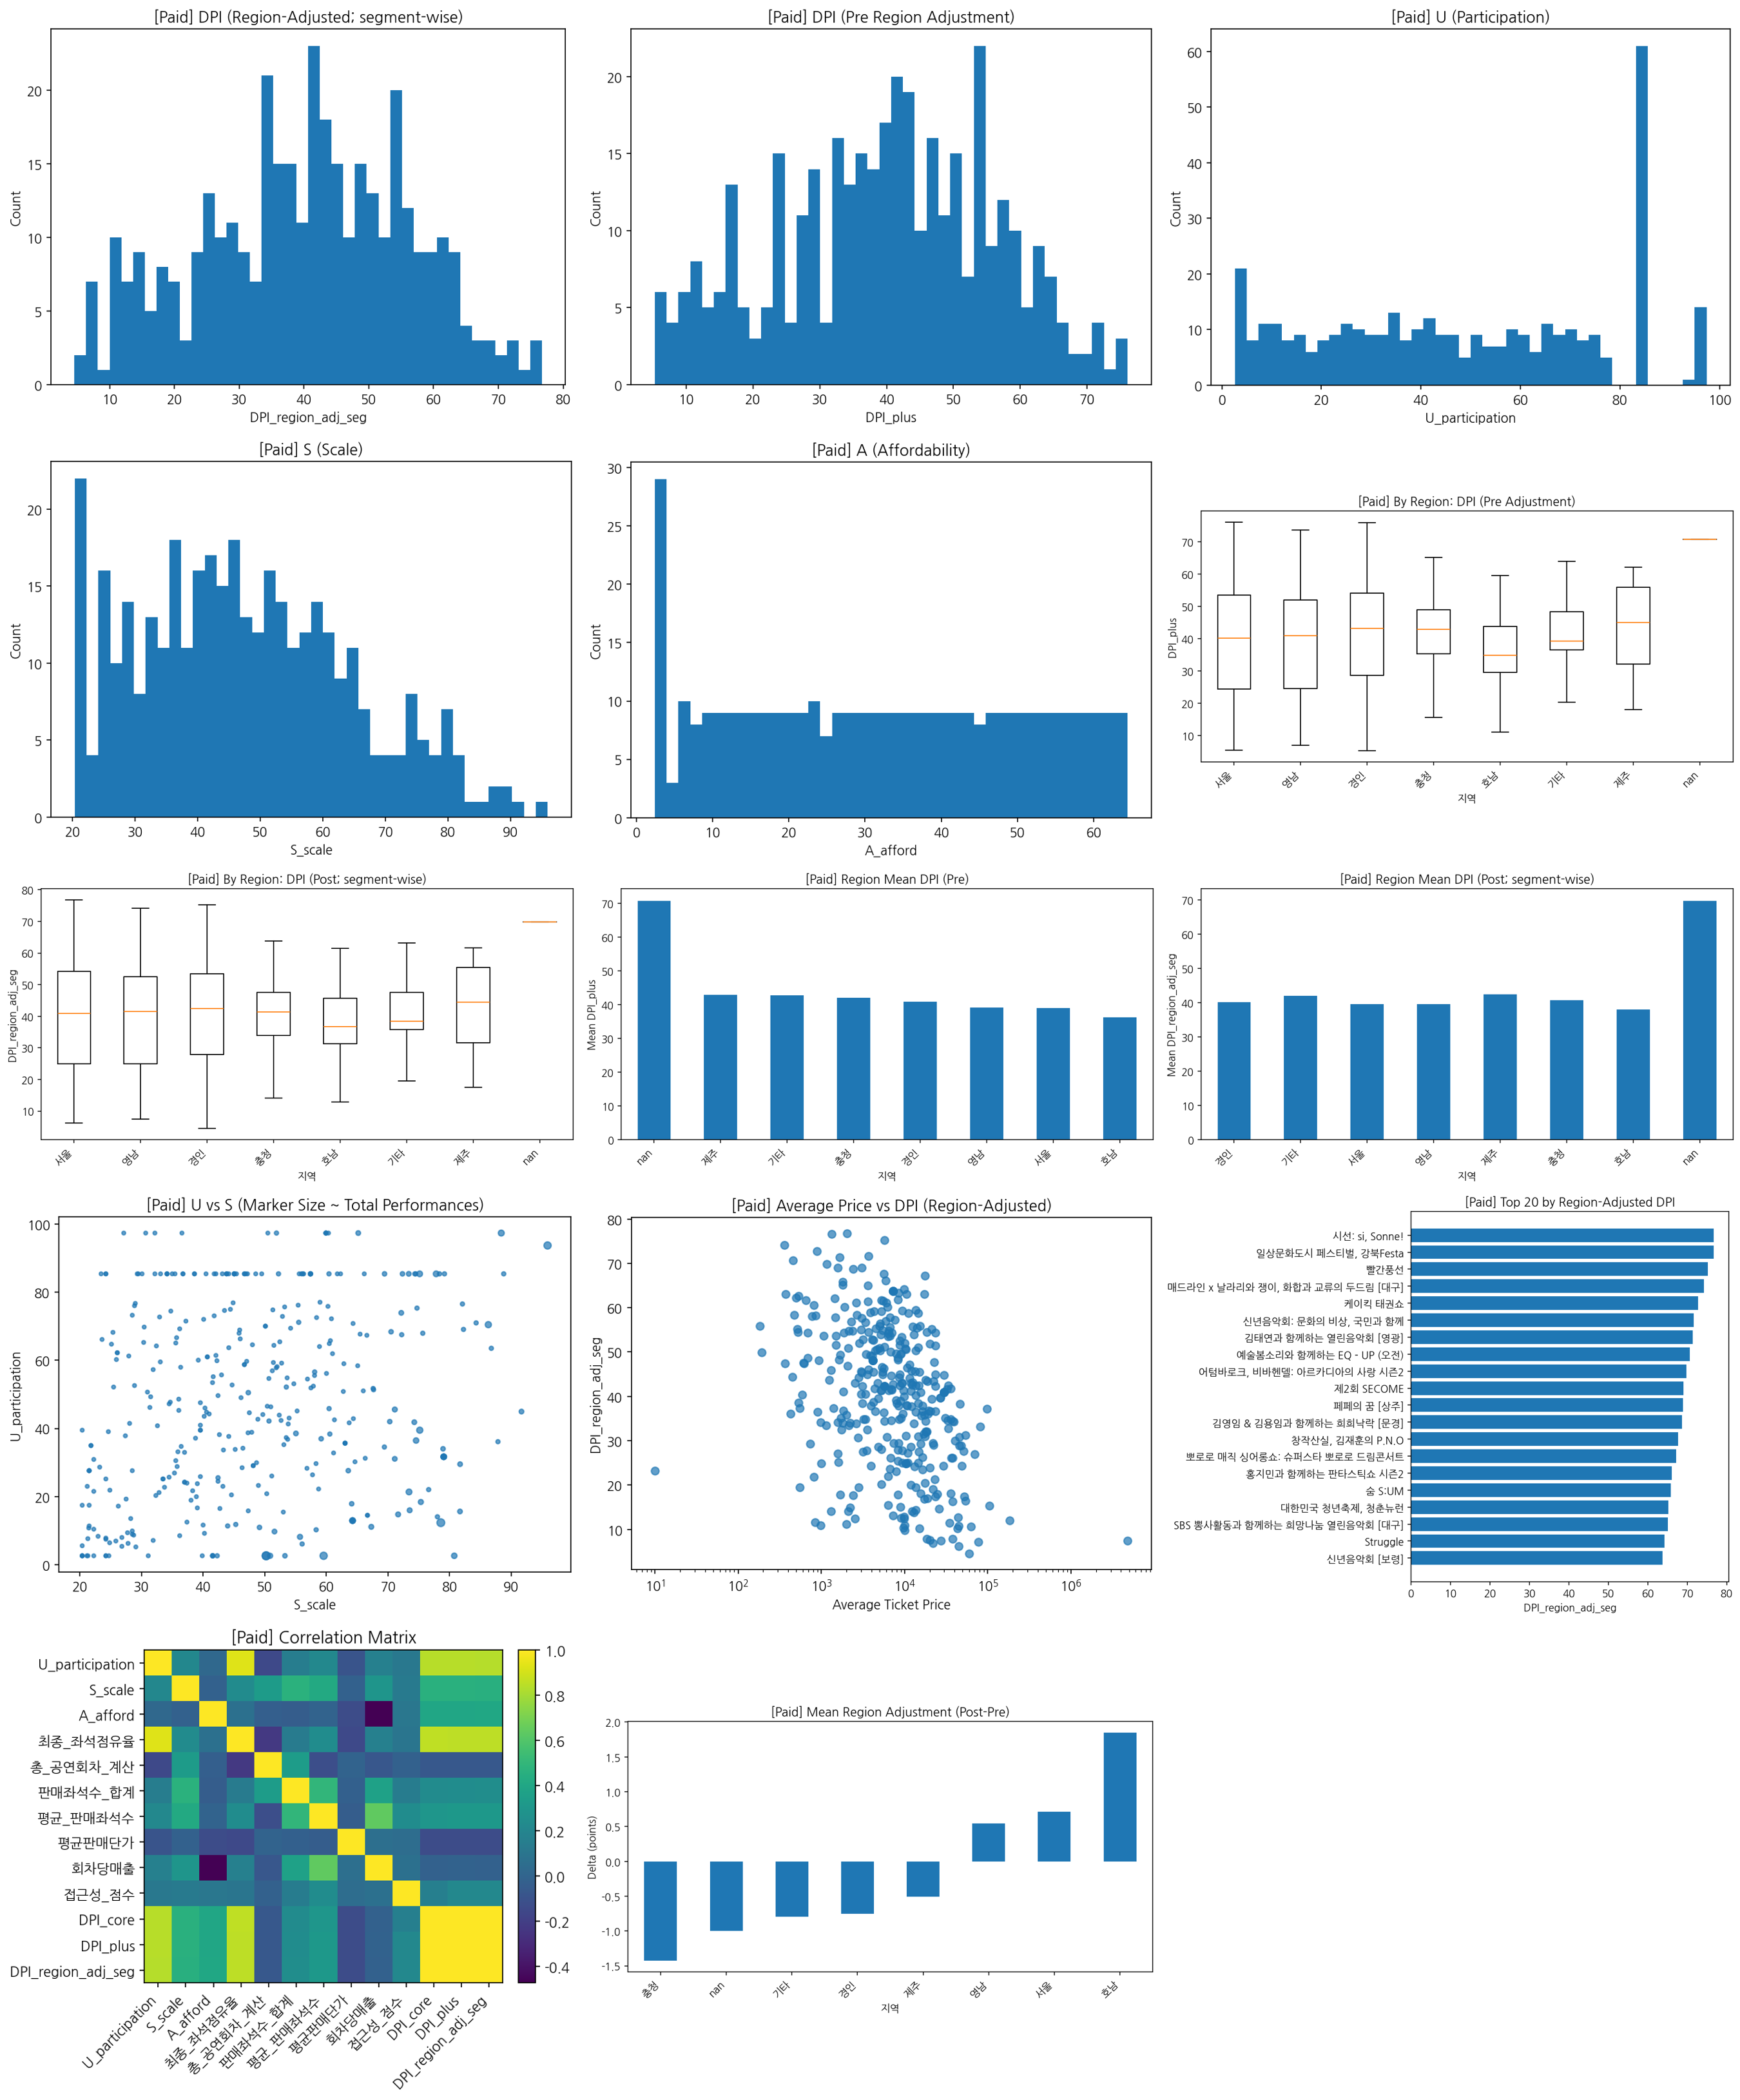

/tmp/ipython-input-3946862438.py:93: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=order, showfliers=False)
/tmp/ipython-input-3946862438.py:93: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=order, showfliers=False)


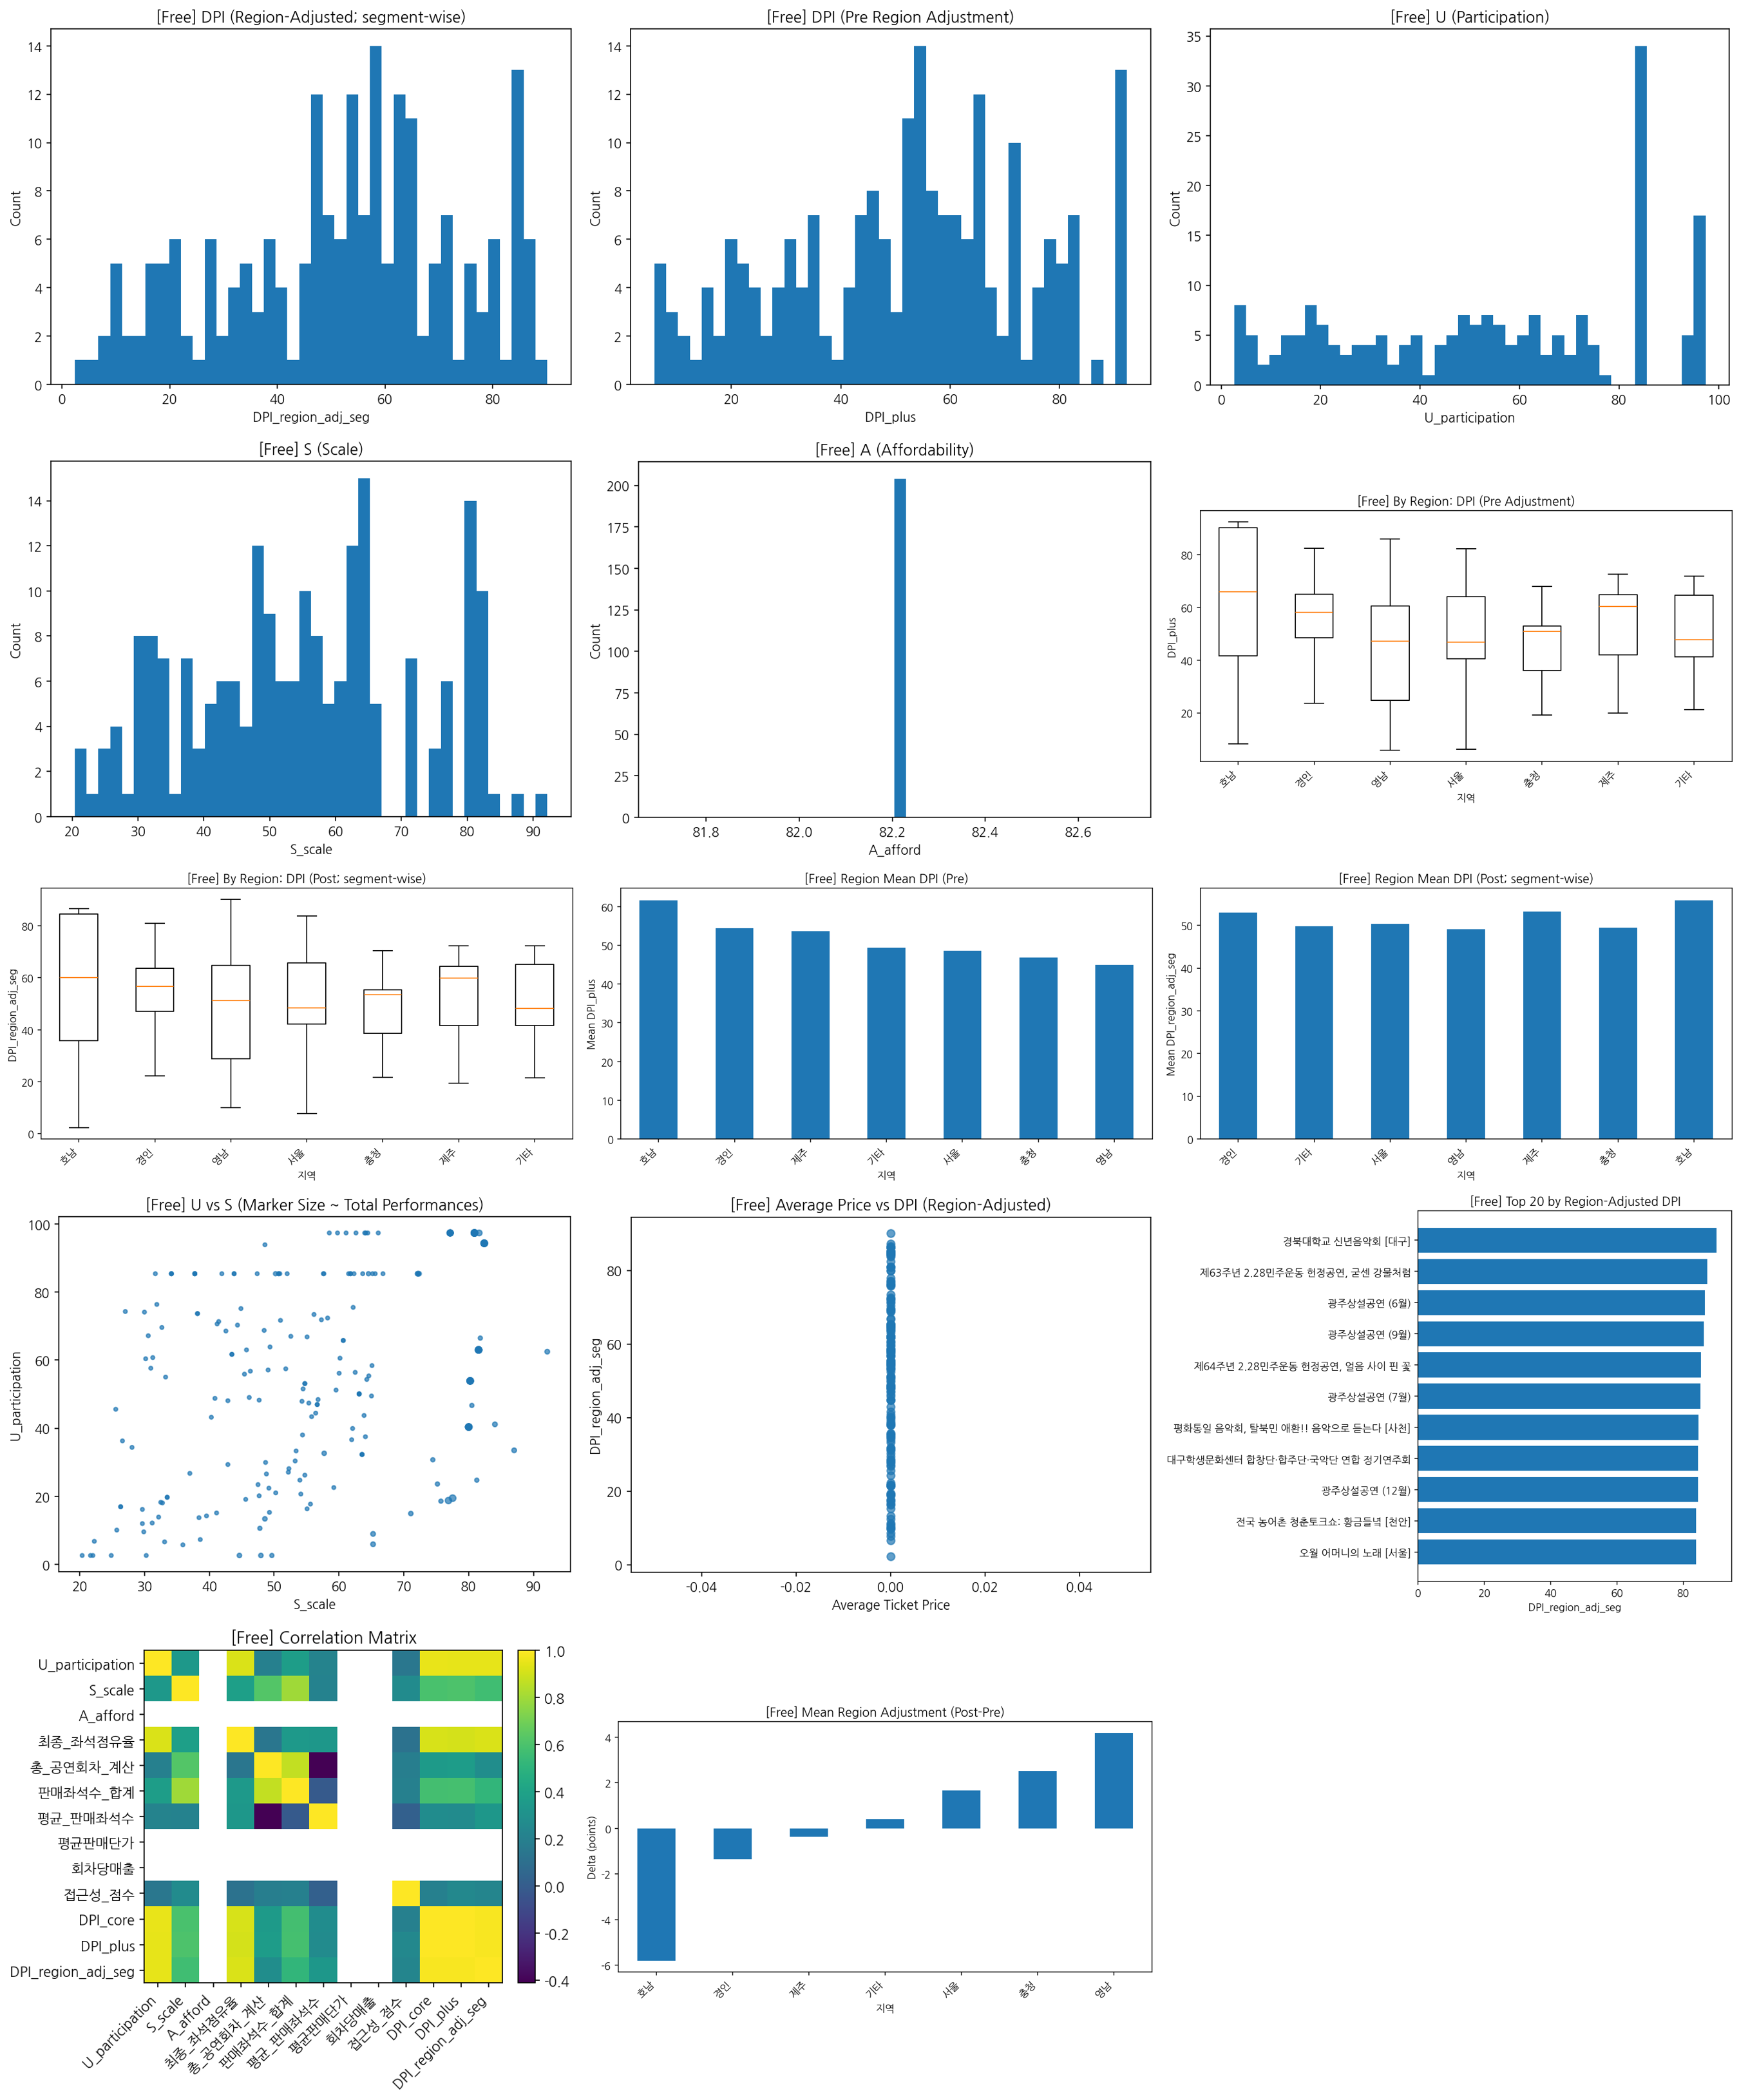

✅ Done. Grids saved under: /content/drive/MyDrive/KOPIS/Hyeon/plots


In [ ]:
# ============================================================
# Paid/Free 분리 지역보정 + 모든 시각화 3개/행 합본 생성
# ============================================================

import os, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# ------------------------------
# 0) 출력 경로 세팅 (원하면 MyDrive로 바꿔도 됨)
# ------------------------------
OUT_DIR = "/content/drive/MyDrive/KOPIS/Hyeon"   # 예: "/content/drive/MyDrive/KOPIS/plots_output"
PLOTS_DIR = os.path.join(OUT_DIR, "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

# ------------------------------
# 1) 준비: 세그먼트 & 보조
# ------------------------------
def cols_exist(d, cols):
    return all(c in d.columns for c in cols)

# is_free 없으면 생성
if "is_free" not in df.columns:
    df["is_free"] = ((df.get("평균판매단가", 0).fillna(0) <= 0) | (df.get("회차당매출", 0).fillna(0) <= 0))

df["segment"] = np.where(df["is_free"], "Free", "Paid")

# ------------------------------
# 2) 유/무료 분리 지역보정 (필요시 계산)
# ------------------------------
REGION_SHRINK_K  = 60   # 표본 작을수록 보정 약화
REGION_CAP_ABS   = 5.0  # 최대 ±5점만 이동

def region_adjust_segment(seg_df, dpi_col="DPI_plus", region_col="지역", k=60, cap=5.0):
    g = seg_df.groupby(region_col, dropna=False)
    mu_region = g[dpi_col].transform("mean")
    mu_all    = float(seg_df[dpi_col].mean())
    n_region  = g[dpi_col].transform("size")
    alpha = (n_region / (n_region + k)).clip(0,1)         # 수축
    delta = np.clip(alpha * (mu_region - mu_all), -cap, cap)  # 이동량 + 캡
    adj = seg_df[dpi_col] - delta
    pr  = g[dpi_col].rank(pct=True, method="average")
    return adj, pr, (adj - seg_df[dpi_col])

# DPI_region_adj_seg 없으면 새로 계산
need_adj = ("DPI_region_adj_seg" not in df.columns) or df["DPI_region_adj_seg"].isna().all()
if need_adj:
    df["DPI_region_adj_seg"] = np.nan
    df["DPI_region_pr_seg"]  = np.nan
    df["region_delta_seg"]   = np.nan
    for seg in ["Paid", "Free"]:
        idx = (df["segment"] == seg)
        if idx.sum() == 0:
            continue
        adj, pr, delta = region_adjust_segment(
            df.loc[idx], dpi_col="DPI_plus", k=REGION_SHRINK_K, cap=REGION_CAP_ABS
        )
        df.loc[idx, "DPI_region_adj_seg"] = adj
        df.loc[idx, "DPI_region_pr_seg"]  = pr
        df.loc[idx, "region_delta_seg"]   = delta

# ------------------------------
# 3) 개별 차트 생성 함수(모두 개별 Figure)
# ------------------------------
def _sanitize_filename(s: str) -> str:
    bad = '<>:"/\\|?*'
    for ch in bad: s = s.replace(ch, "_")
    return s

def _save_current_fig(path: str):
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight", dpi=150)
    plt.close()

def plot_hist(series, title, xlabel, fname):
    s = pd.to_numeric(series, errors="coerce").dropna()
    if s.size == 0: return None
    plt.figure()
    plt.hist(s, bins=40)
    plt.title(title); plt.xlabel(xlabel); plt.ylabel("Count")
    out = os.path.join(PLOTS_DIR, _sanitize_filename(fname) + ".png")
    _save_current_fig(out); return out

def plot_box_by_cat(df_sub, value_col, cat_col, title, ylabel, fname):
    if not cols_exist(df_sub, [value_col, cat_col]): return None
    order = df_sub[cat_col].astype(str).fillna("(NaN)").value_counts().index.tolist()
    data  = [pd.to_numeric(df_sub.loc[df_sub[cat_col].astype(str).fillna("(NaN)")==r, value_col],
                           errors="coerce").dropna() for r in order]
    if not any(len(d)>0 for d in data): return None
    plt.figure(figsize=(8, 4.5))
    plt.boxplot(data, labels=order, showfliers=False)
    plt.title(title); plt.xlabel(cat_col); plt.ylabel(ylabel)
    plt.xticks(rotation=45, ha="right")
    out = os.path.join(PLOTS_DIR, _sanitize_filename(fname) + ".png")
    _save_current_fig(out); return out

def plot_bar_series(series, title, ylabel, fname):
    s = pd.to_numeric(series, errors="coerce").dropna()
    if s.size == 0: return None
    plt.figure(figsize=(8, 4.5))
    s.plot(kind="bar")
    plt.title(title); plt.ylabel(ylabel)
    plt.xticks(rotation=45, ha="right")
    out = os.path.join(PLOTS_DIR, _sanitize_filename(fname) + ".png")
    _save_current_fig(out); return out

def plot_scatter(x, y, title, xlabel, ylabel, fname, sizes=None, logx=False):
    x = pd.to_numeric(x, errors="coerce"); y = pd.to_numeric(y, errors="coerce")
    mask = x.notna() & y.notna()
    if mask.sum() == 0: return None
    plt.figure()
    if sizes is not None:
        ss = pd.to_numeric(sizes, errors="coerce").fillna(0)
        ss = np.sqrt(ss.clip(lower=0) + 1) * 6
        plt.scatter(x[mask], y[mask], s=ss[mask], alpha=0.7)
    else:
        plt.scatter(x[mask], y[mask], alpha=0.7)
    plt.title(title); plt.xlabel(xlabel); plt.ylabel(ylabel)
    if logx:
        try:
            if x[mask].max() > 0: plt.xscale("log")
        except Exception: pass
    out = os.path.join(PLOTS_DIR, _sanitize_filename(fname) + ".png")
    _save_current_fig(out); return out

def plot_barh_top(df_sub, value_col, label_col, topN, title, xlabel, fname):
    if not cols_exist(df_sub, [value_col, label_col]): return None
    sub = df_sub[[label_col, value_col]].dropna().sort_values(value_col, ascending=False).head(topN)
    if sub.empty: return None
    plt.figure(figsize=(8, max(4, topN*0.3)))
    plt.barh(sub[label_col][::-1], sub[value_col][::-1])
    plt.title(title); plt.xlabel(xlabel)
    out = os.path.join(PLOTS_DIR, _sanitize_filename(fname) + ".png")
    _save_current_fig(out); return out

def plot_corr_heatmap(df_sub, cols, title, fname):
    cols = [c for c in cols if c in df_sub.columns]
    if len(cols) < 3: return None
    cdf = df_sub[cols].apply(pd.to_numeric, errors="coerce")
    if cdf.dropna(how="all").empty: return None
    corr = cdf.corr()
    plt.figure(figsize=(6, 5))
    im = plt.imshow(corr.values, aspect="auto")
    plt.title(title)
    plt.xticks(range(len(cols)), cols, rotation=45, ha="right")
    plt.yticks(range(len(cols)), cols)
    plt.colorbar(im, fraction=0.046, pad=0.04)
    out = os.path.join(PLOTS_DIR, _sanitize_filename(fname) + ".png")
    _save_current_fig(out); return out

# ------------------------------
# 4) 합본 이미지(3개/행) 생성
# ------------------------------
def make_grid(image_paths, grid_name, per_row=3, thumb_w=900, bg=(255,255,255)):
    paths = [p for p in image_paths if p is not None and os.path.exists(p)]
    if not paths: return None
    imgs = []
    for p in paths:
        im = Image.open(p).convert("RGB")
        w, h = im.size
        if w != thumb_w:
            new_h = int(h * (thumb_w / max(1, w)))
            im = im.resize((thumb_w, new_h))
        imgs.append(im)
    rows = math.ceil(len(imgs) / per_row)
    row_heights = []
    grid_w = per_row * thumb_w
    for r in range(rows):
        row = imgs[r*per_row:(r+1)*per_row]
        row_heights.append(max(im.size[1] for im in row))
    grid_h = sum(row_heights)
    grid = Image.new("RGB", (grid_w, grid_h), bg)
    y = 0; idx = 0
    for r in range(rows):
        x = 0; rh = row_heights[r]
        for c in range(per_row):
            if idx >= len(imgs): break
            im = imgs[idx]
            y_offset = (rh - im.size[1]) // 2
            grid.paste(im, (x, y + y_offset))
            x += thumb_w; idx += 1
        y += rh
    out_path = os.path.join(PLOTS_DIR, _sanitize_filename(grid_name) + ".png")
    grid.save(out_path, format="PNG")
    return out_path

# ------------------------------
# 5) 세그먼트별 차트 생성 + 합본
# ------------------------------
segments = ["Paid", "Free"]
grid_paths = []

for seg in segments:
    seg_df = df[df["segment"] == seg].copy()
    if seg_df.empty:
        print(f"{seg}: 데이터 없음")
        continue

    charts = []
    # (1) DPI 분포
    charts.append(plot_hist(seg_df.get("DPI_region_adj_seg"),
                            f"[{seg}] DPI (Region-Adjusted; segment-wise)",
                            "DPI_region_adj_seg", f"{seg}_dist_DPI_region_adj_seg"))
    charts.append(plot_hist(seg_df.get("DPI_plus"),
                            f"[{seg}] DPI (Pre Region Adjustment)",
                            "DPI_plus", f"{seg}_dist_DPI_plus"))

    # (2) U/S/A 분포
    charts.append(plot_hist(seg_df.get("U_participation"), f"[{seg}] U (Participation)", "U_participation", f"{seg}_dist_U"))
    charts.append(plot_hist(seg_df.get("S_scale"),         f"[{seg}] S (Scale)",         "S_scale",         f"{seg}_dist_S"))
    charts.append(plot_hist(seg_df.get("A_afford"),        f"[{seg}] A (Affordability)", "A_afford",        f"{seg}_dist_A"))

    # (3) 지역별 박스플롯 (전/후)
    charts.append(plot_box_by_cat(seg_df, "DPI_plus", "지역",
                                  f"[{seg}] By Region: DPI (Pre Adjustment)", "DPI_plus",
                                  f"{seg}_box_region_pre"))
    charts.append(plot_box_by_cat(seg_df, "DPI_region_adj_seg", "지역",
                                  f"[{seg}] By Region: DPI (Post; segment-wise)", "DPI_region_adj_seg",
                                  f"{seg}_box_region_post"))

    # (4) 지역 평균 바 (전/후)
    if cols_exist(seg_df, ["지역","DPI_plus"]):
        reg_pre = seg_df.groupby("지역", dropna=False)["DPI_plus"].mean().sort_values(ascending=False)
        charts.append(plot_bar_series(reg_pre, f"[{seg}] Region Mean DPI (Pre)", "Mean DPI_plus", f"{seg}_bar_region_mean_pre"))
    if cols_exist(seg_df, ["지역","DPI_region_adj_seg"]):
        reg_post = seg_df.groupby("지역", dropna=False)["DPI_region_adj_seg"].mean()
        charts.append(plot_bar_series(reg_post, f"[{seg}] Region Mean DPI (Post; segment-wise)", "Mean DPI_region_adj_seg", f"{seg}_bar_region_mean_post"))

    # (5) 산점: U vs S (size = 회차)
    charts.append(plot_scatter(seg_df.get("S_scale"), seg_df.get("U_participation"),
                               f"[{seg}] U vs S (Marker Size ~ Total Performances)",
                               "S_scale", "U_participation",
                               f"{seg}_scatter_U_vs_S",
                               sizes=seg_df.get("총_공연회차_계산"), logx=False))

    # (6) 산점: Price vs DPI (post)
    charts.append(plot_scatter(seg_df.get("평균판매단가"), seg_df.get("DPI_region_adj_seg"),
                               f"[{seg}] Average Price vs DPI (Region-Adjusted)",
                               "Average Ticket Price", "DPI_region_adj_seg",
                               f"{seg}_scatter_price_vs_DPI",
                               sizes=None, logx=True))

    # (7) Top-20
    charts.append(plot_barh_top(seg_df, "DPI_region_adj_seg", "공연명", 20,
                                f"[{seg}] Top 20 by Region-Adjusted DPI",
                                "DPI_region_adj_seg", f"{seg}_top20"))

    # (8) 상관 히트맵
    charts.append(plot_corr_heatmap(
        seg_df,
        ["U_participation","S_scale","A_afford","최종_좌석점유율","총_공연회차_계산","판매좌석수_합계",
         "평균_판매좌석수","평균판매단가","회차당매출","접근성_점수","DPI_core","DPI_plus","DPI_region_adj_seg"],
        f"[{seg}] Correlation Matrix", f"{seg}_corr"
    ))

    # (9) 지역보정 델타
    if cols_exist(seg_df, ["region_delta_seg","지역"]):
        reg_delta = seg_df.groupby("지역", dropna=False)["region_delta_seg"].mean().sort_values()
        charts.append(plot_bar_series(reg_delta, f"[{seg}] Mean Region Adjustment (Post-Pre)", "Delta (points)", f"{seg}_bar_region_delta"))

    # 합본(3개/행) 생성 + 표시
    grid = make_grid([p for p in charts if p], grid_name=f"{seg}_ALL_CHARTS_3perRow", per_row=3, thumb_w=900)
    if grid:
        grid_paths.append(grid)
        from IPython.display import Image as IPyImage, display as ipy_display
        ipy_display(IPyImage(filename=grid))

print("✅ Done. Grids saved under:", PLOTS_DIR)


In [ ]:
region_sales = df.groupby("지역")["예매금액_합계"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
region_sales.plot(kind="bar")
plt.title("지역별 총 매출")
plt.ylabel("총 매출 (예매금액 합계)")
plt.xlabel("지역")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
